## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

In [3]:
# Carregar o arquivo CSV
df = pd.read_csv('housing.csv')

# Mostrar as primeiras linhas do DataFrame
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


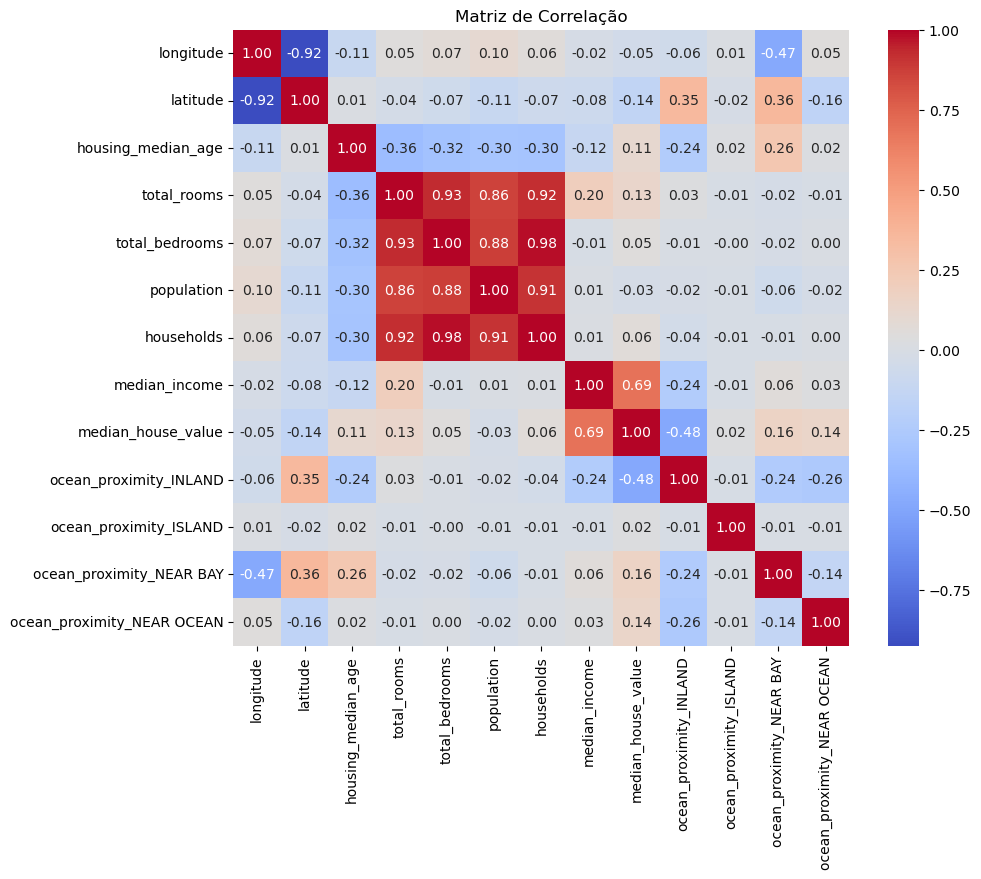

Dimensão dos dados de treinamento: (14303, 12)
Dimensão dos dados de validação: (3065, 12)
Dimensão dos dados de teste: (3065, 12)


In [5]:
print(df.isnull().sum())

# Remover valores NaN
df = df.dropna()

#Codificação de variáveis categóricas
df = pd.get_dummies(df, drop_first=True)

# Calculando a matriz de correlação
correlation_matrix = df.corr()

# Visualizando o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Matriz de Correlação')
plt.show()

#Separação de features (X) e target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Dividir os dados em treinamento, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% treino
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validação, 15% teste

print(f"Dimensão dos dados de treinamento: {X_train.shape}")
print(f"Dimensão dos dados de validação: {X_val.shape}")
print(f"Dimensão dos dados de teste: {X_test.shape}")

In [7]:
# Treinando a árvore com profundidade máxima = 8
tree_depth_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_depth_8.fit(X_train, y_train)

# Treinando a árvore com profundidade máxima = 2
tree_depth_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_depth_2.fit(X_train, y_train)

# Exibindo os resultados básicos
print("Árvore com profundidade máxima = 8 treinada!")
print("Árvore com profundidade máxima = 2 treinada!")

Árvore com profundidade máxima = 8 treinada!
Árvore com profundidade máxima = 2 treinada!


In [9]:
# Fazendo previsões nas bases de treinamento e teste para a árvore com profundidade máxima = 8
y_train_pred_8 = tree_depth_8.predict(X_train)
y_test_pred_8 = tree_depth_8.predict(X_test)

# Calculando o MSE para a árvore com profundidade máxima = 8
mse_train_8 = mean_squared_error(y_train, y_train_pred_8)
mse_test_8 = mean_squared_error(y_test, y_test_pred_8)

print(f"MSE da Árvore (profundidade = 8) - Treinamento: {mse_train_8:.2f}")
print(f"MSE da Árvore (profundidade = 8) - Teste: {mse_test_8:.2f}")

# Fazendo previsões nas bases de treinamento e teste para a árvore com profundidade máxima = 2
y_train_pred_2 = tree_depth_2.predict(X_train)
y_test_pred_2 = tree_depth_2.predict(X_test)

# Calculando o MSE para a árvore com profundidade máxima = 2
mse_train_2 = mean_squared_error(y_train, y_train_pred_2)
mse_test_2 = mean_squared_error(y_test, y_test_pred_2)

print(f"MSE da Árvore (profundidade = 2) - Treinamento: {mse_train_2:.2f}")
print(f"MSE da Árvore (profundidade = 2) - Teste: {mse_test_2:.2f}")

MSE da Árvore (profundidade = 8) - Treinamento: 3155880403.70
MSE da Árvore (profundidade = 8) - Teste: 3881688746.43
MSE da Árvore (profundidade = 2) - Treinamento: 6712935748.76
MSE da Árvore (profundidade = 2) - Teste: 6814196954.22


### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

In [13]:
# Calculando o caminho dos CCP-alphas
path = tree_depth_2.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Exibindo os valores calculados
print("CCP-alphas:", ccp_alphas)
print("Impurezas:", impurities)

CCP-alphas: [0.00000000e+00 7.87644763e+08 1.67507785e+09 4.14584245e+09]
Impurezas: [6.71293575e+09 7.50058051e+09 9.17565836e+09 1.33215008e+10]


### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

In [15]:
# Lista para armazenar as árvores treinadas
trees = []

# Treinando uma árvore para cada valor de alpha
for alpha in ccp_alphas:
    tree = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    tree.fit(X_train, y_train)
    trees.append(tree)

print(f"{len(trees)} árvores foram treinadas e armazenadas na lista!")

4 árvores foram treinadas e armazenadas na lista!


### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [17]:
from sklearn.metrics import mean_squared_error

# Listas para armazenar os resultados do MSE
mse_train_list = []
mse_test_list = []

# Iterar sobre cada árvore treinada
for tree in trees:
    # Previsões para treinamento e teste
    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)
    
    # Cálculo do MSE
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    # Armazenando os resultados
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

# Exibindo os resultados
for i, alpha in enumerate(ccp_alphas):
    print(f"Alpha: {alpha:.2f}")
    print(f"MSE Treinamento: {mse_train_list[i]:.2f}")
    print(f"MSE Teste: {mse_test_list[i]:.2f}")
    print("-" * 30)

Alpha: 0.00
MSE Treinamento: 0.00
MSE Teste: 4622602071.95
------------------------------
Alpha: 787644763.05
MSE Treinamento: 6712935748.76
MSE Teste: 6814196954.22
------------------------------
Alpha: 1675077845.82
MSE Treinamento: 7500580511.80
MSE Teste: 7543595932.45
------------------------------
Alpha: 4145842453.65
MSE Treinamento: 13321500811.26
MSE Teste: 13315937907.46
------------------------------


### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

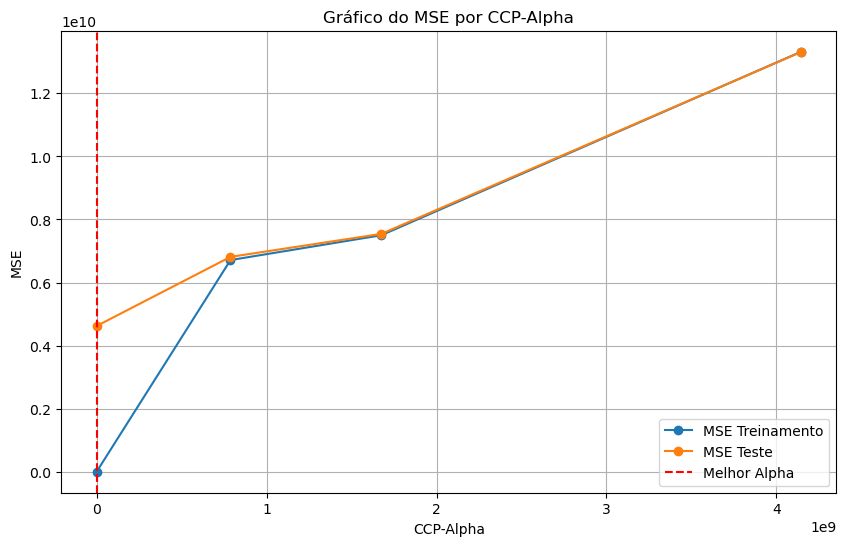

O melhor alpha (mínimo MSE de teste) é: 0.00


In [19]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, mse_train_list, marker='o', label='MSE Treinamento')
plt.plot(ccp_alphas, mse_test_list, marker='o', label='MSE Teste')
plt.axvline(x=ccp_alphas[mse_test_list.index(min(mse_test_list))], color='red', linestyle='--', label='Melhor Alpha')
plt.xlabel("CCP-Alpha")
plt.ylabel("MSE")
plt.title("Gráfico do MSE por CCP-Alpha")
plt.legend()
plt.grid()
plt.show()

# Melhor alpha
melhor_alpha = ccp_alphas[mse_test_list.index(min(mse_test_list))]
print(f"O melhor alpha (mínimo MSE de teste) é: {melhor_alpha:.2f}")


### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [30]:
# Melhor árvore com o alpha selecionado
melhor_arvore = trees[mse_test_list.index(min(mse_test_list))]

# Calculando o R-quadrado para os dados de teste
r2_treino = melhor_arvore.score(X_train, y_train)
r2_teste = melhor_arvore.score(X_test, y_test)

# Exibindo os resultados
print(f"R-quadrado (Treinamento): {r2_treino:.2f}")
print(f"R-quadrado (Teste): {r2_teste:.2f}")


R-quadrado (Treinamento): 1.00
R-quadrado (Teste): 0.65


### 7. Visualize esta árvore.

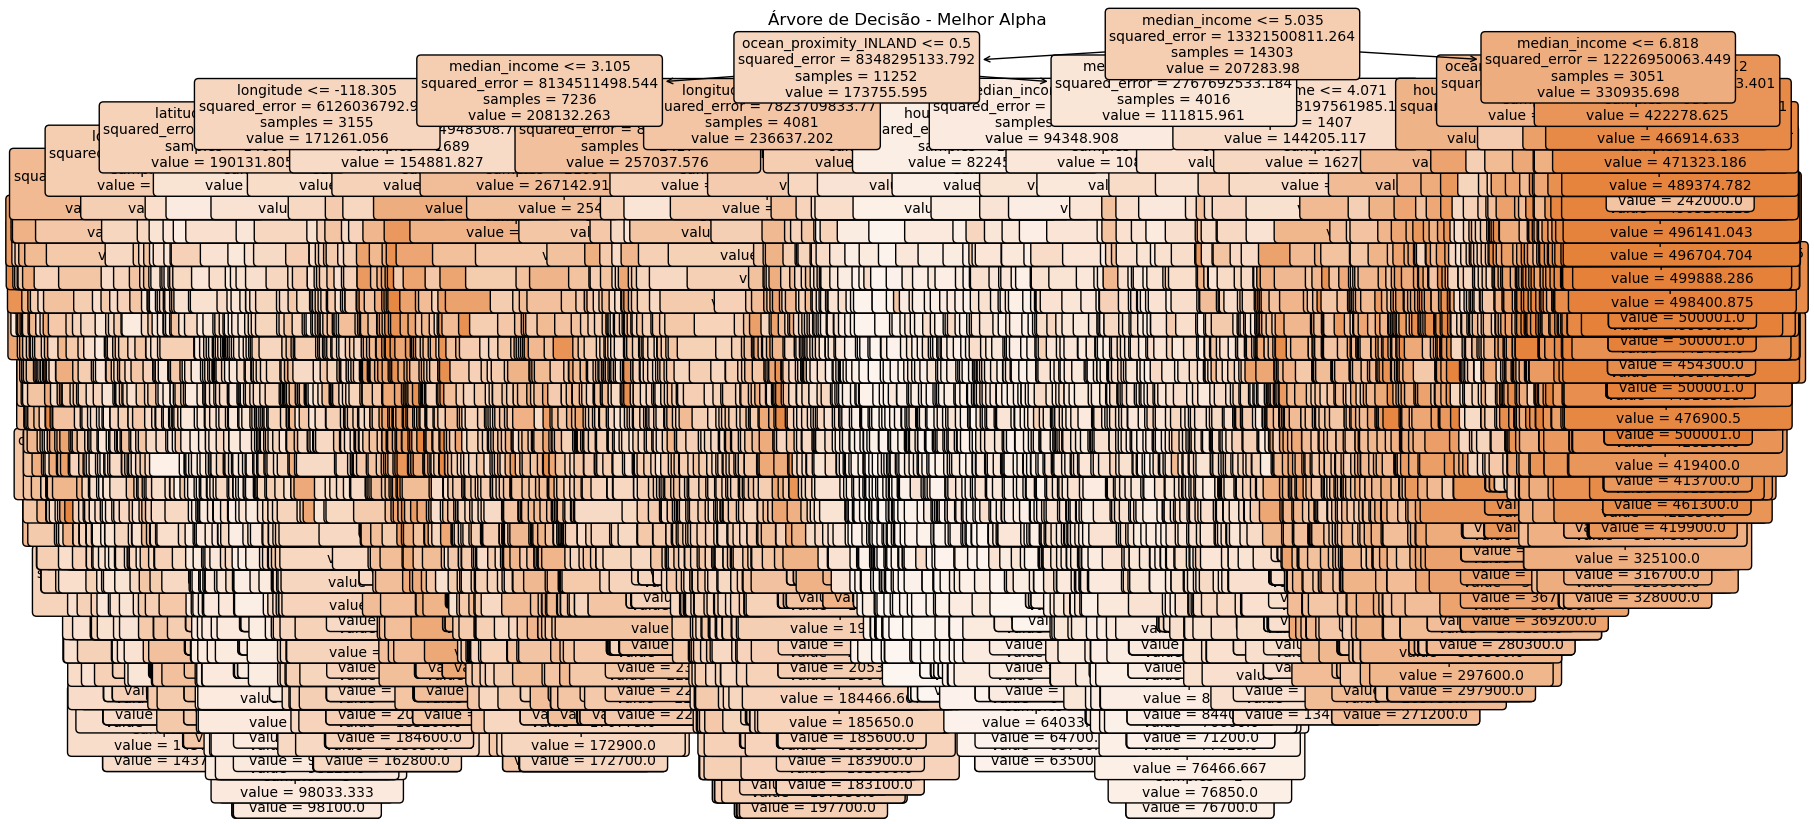

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualizar a melhor árvore
plt.figure(figsize=(20, 10))
plot_tree(melhor_arvore, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão - Melhor Alpha")
plt.show()


Ao observar a árvore, fica evidente que variáveis como median_income aparecem com destaque nos nós superiores, sugerindo que ela tem grande impacto nas decisões iniciais. Isso faz sentido, pois renda mediana é um forte indicador em muitas análises de valor de casas.